In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt

from lmfit.model import load_modelresult


In [2]:
ROOT = Path.cwd()  

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR 
import results_comp
import ci_results_compiler
import plot_fit_params
import list_maps_plots


# Loading files

In [3]:
filelist = "fits_ready/filelist_results.txt"

with open(filelist, "r", encoding="utf-8") as f:
    names = [line.strip() for line in f if line.strip()]

In [4]:
names

['LVM-30Dor-6563_subrot',
 'LVM-30Dor-6563_rot',
 'LVM-30Dor-6583_subrot',
 'LVM-30Dor-6583_rot',
 'LVM-30Dor-3729_subrot',
 'LVM-30Dor-3729_rot',
 'LVM-30Dor-5007_subrot',
 'LVM-30Dor-5007_rot',
 'LVM-30Dor-6731_subrot',
 'LVM-30Dor-6731_rot',
 'LVM-30Dor-9069_subrot',
 'LVM-30Dor-9069_rot']

In [5]:
bundles = {}

for name in names:
    bundles[name] = results_comp.load_line_bundle(
        name, name, MAPS_DIR, read_header=True
    )

In [6]:
#bundles["LVM-30Dor-6563_subrot"]

In [7]:
dfs_obs  = {name: bundle["obs"]  for name, bundle in bundles.items()}
dfs_fit  = {name: bundle["fit"]  for name, bundle in bundles.items()}
meta_all = {name: bundle["meta"] for name, bundle in bundles.items()}

In [8]:
#dfs_obs["LVM-30Dor-6563_subrot"]

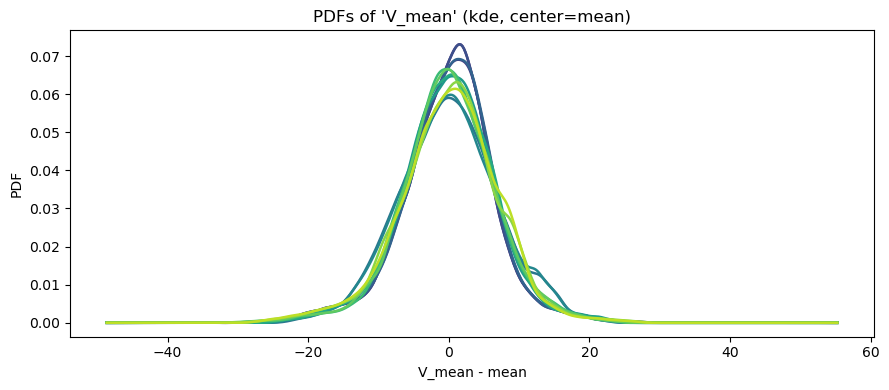

In [9]:
fig, ax, stats_df = list_maps_plots.plot_list_pdfs_circles(
    dfs_obs,
    col="V_mean",
    center="mean",
    method="kde",
    cmap="viridis",
    legend_mode="none",
    annotate=False,
    figsize=(9, 4),
    bw_scale=1.0
)

In [10]:
stats_df

,name,N,mean,std,var,xmin,xmax
0,LVM-30Dor-6563_subrot,30698,-2.758598,6.815309,46.448432,-43.911658,50.519330
1,LVM-30Dor-6563_rot,30698,267.304442,6.847333,46.885971,-43.765342,50.507058
2,LVM-30Dor-6583_subrot,30694,-2.758234,6.815316,46.448536,-43.912023,50.518966
3,LVM-30Dor-6583_rot,30630,267.251459,6.654380,44.280771,-27.233159,26.851041
4,LVM-30Dor-3729_subrot,30579,-6.162892,7.107723,50.519726,-23.670591,24.061766
5,LVM-30Dor-3729_rot,30579,263.899824,7.167029,51.366303,-23.882424,23.096176
6,LVM-30Dor-5007_subrot,30577,-4.771892,6.700938,44.902568,-25.852673,25.296592
7,LVM-30Dor-5007_rot,30577,265.291412,6.686986,44.715783,-25.163112,24.631388
8,LVM-30Dor-6731_subrot,30640,0.602283,6.736668,45.382702,-30.021098,24.797254
9,LVM-30Dor-6731_rot,30644,270.660971,6.818278,46.488913,-33.334171,24.333629


In [11]:
#dfs_fit['LVM-30Dor-6563_subrot']

In [12]:
#labels = ['H_corr', 'H']
labels = [name.replace("LVM-30Dor-", "") for name in names]
labels

['6563_subrot',
 '6563_rot',
 '6583_subrot',
 '6583_rot',
 '3729_subrot',
 '3729_rot',
 '5007_subrot',
 '5007_rot',
 '6731_subrot',
 '6731_rot',
 '9069_subrot',
 '9069_rot']

In [13]:
#obs_var = [dfs_obs["LVM-30Dor-6563_subrot"]['V_mean'].var(), 
#           dfs_obs["LVM-30Dor-6563_rot"]['V_mean'].var()
#          ]
#obs_var
obs_var = [meta_all[name]["SIG2"] for name in names]

In [14]:
fit_tables = [dfs_fit[name] for name in names]

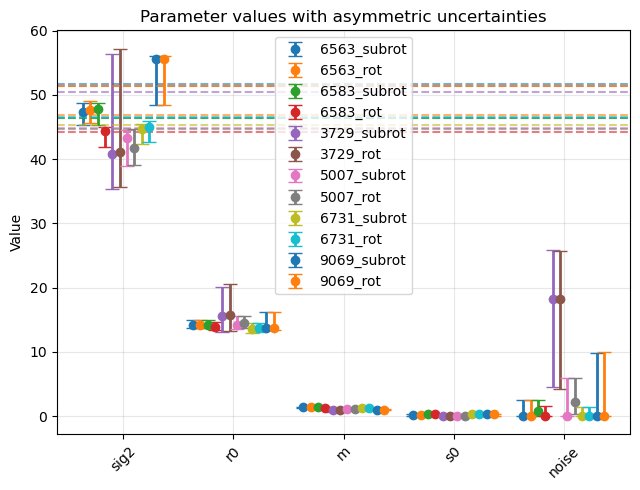

In [15]:
plot_fit_params.plot_param_comp_obs(
    *fit_tables,
    labels=labels,
    obs=obs_var
)

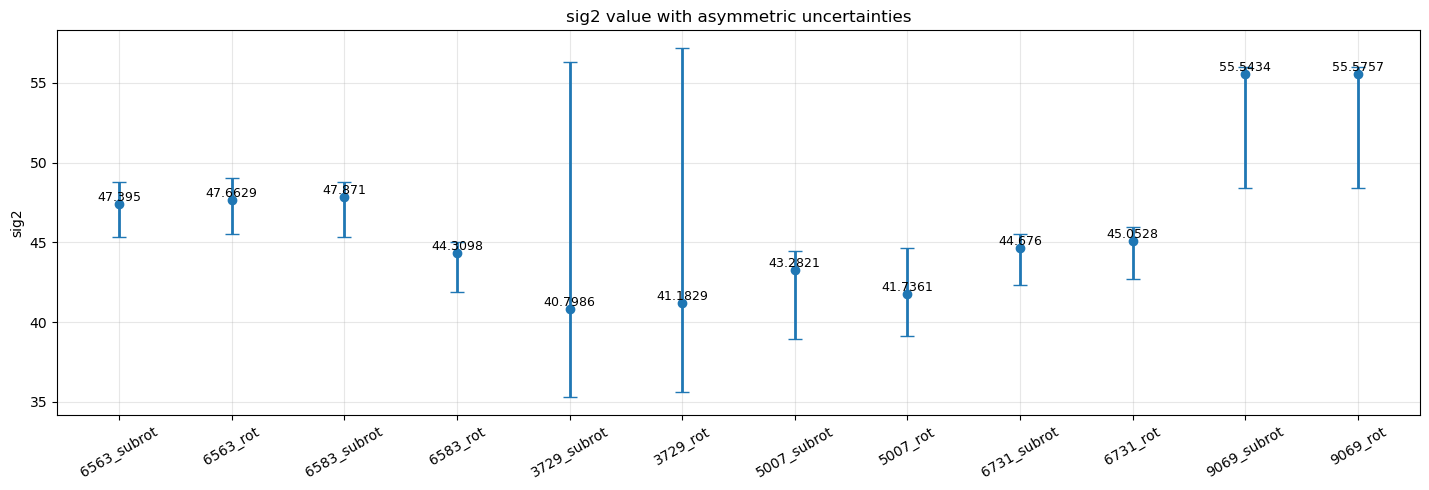

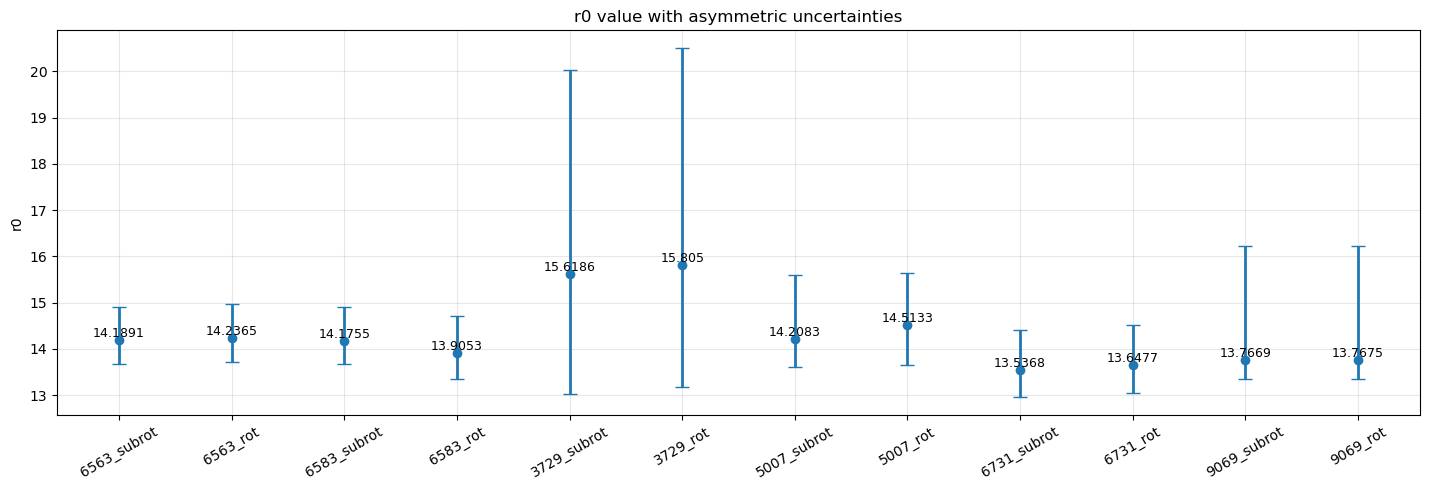

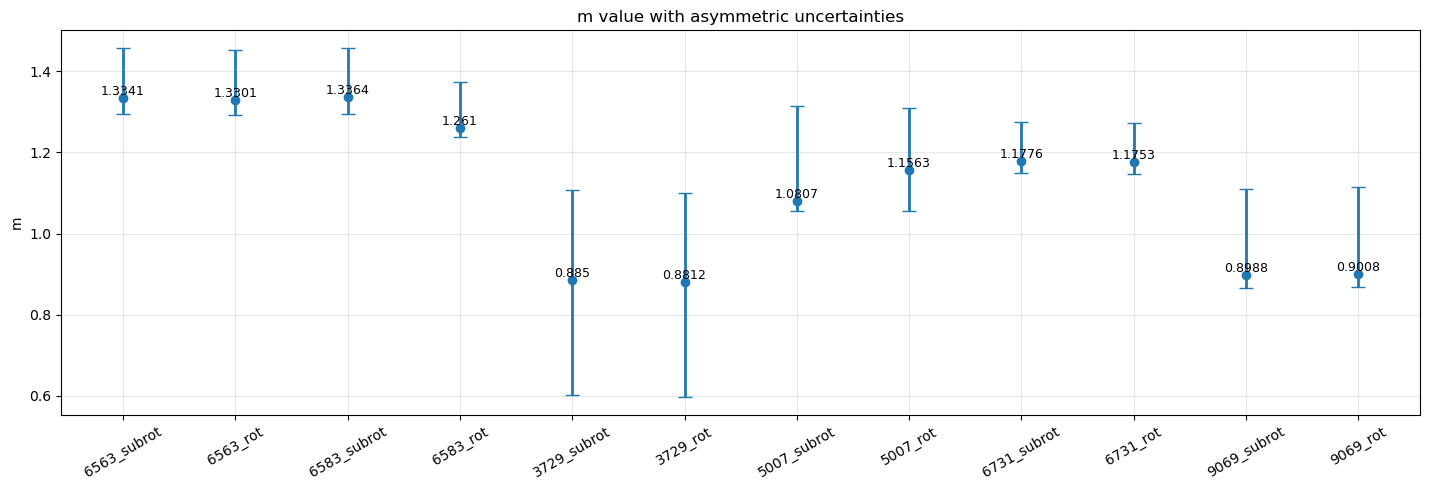

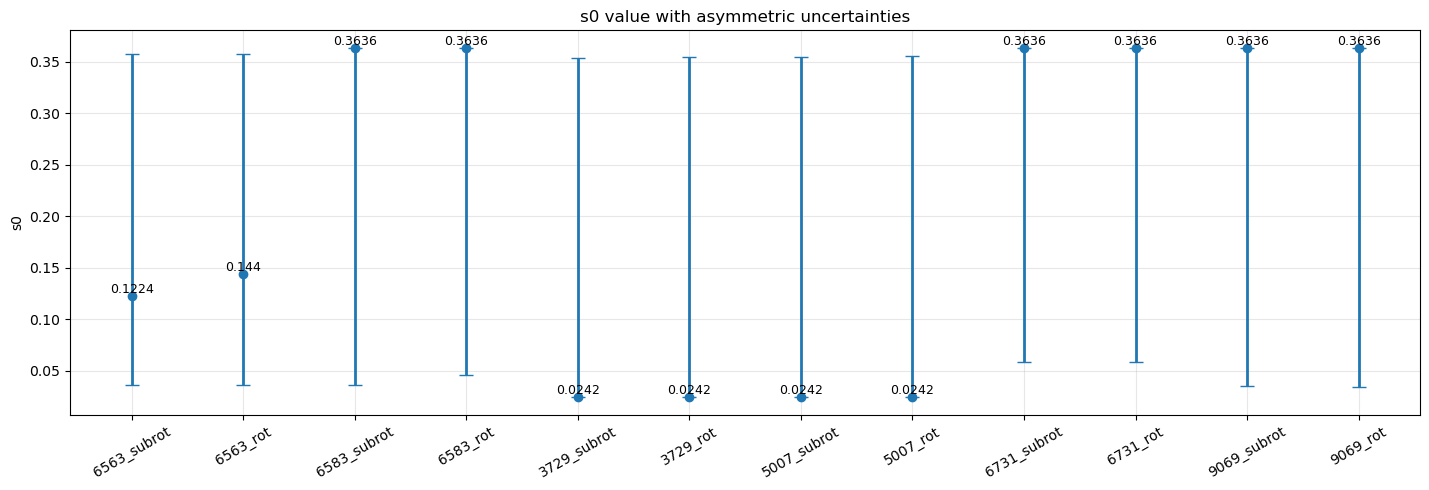

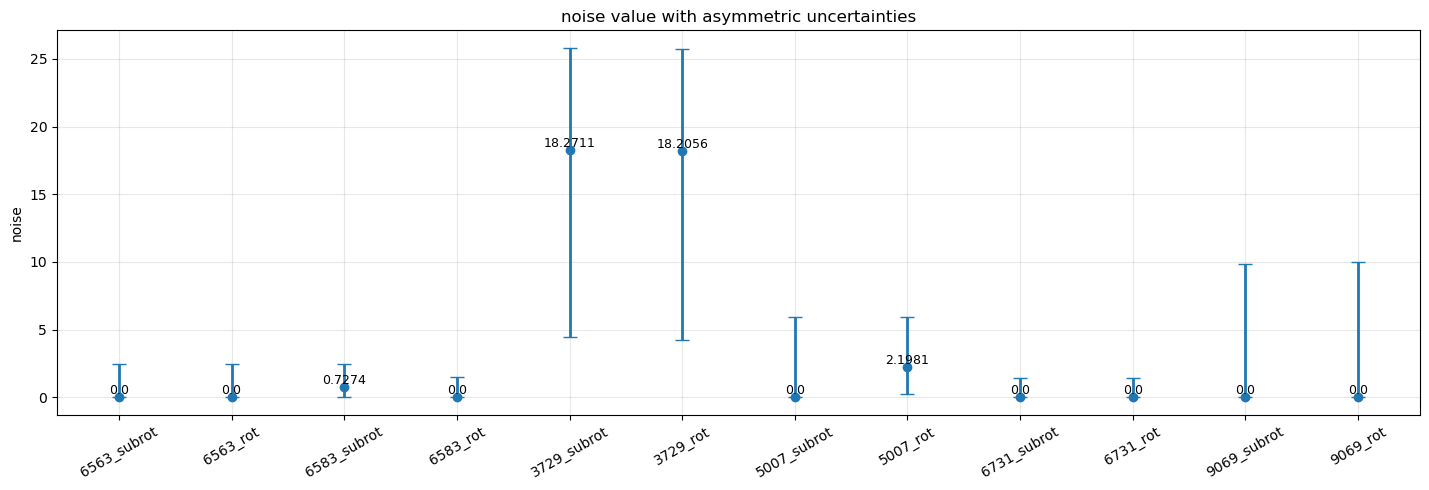

In [16]:
plot_fit_params.plot_param(
    *fit_tables,
    labels=labels,
    decimals=4
)

In [17]:
#plot_fit_params.plot_param(dfs_fit['LVM-30Dor-6563_rot'],
#                                    dfs_fit['LVM-30Dor-6563_subrot'], 
#                                    labels=labels,
#                                decimals=4)